# Ichimoku-Cloud — a quantitative teardown
### Daily tape · symmetric ATR barriers · random-direction control · HAC inference · no-look-ahead cloud

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Partial](https://img.shields.io/badge/Beats_a_coin%3F-Partial-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Ichimoku composite signal (price-vs-cloud + Tenkan/Kijun cross) beats a random-direction control on a symmetric-barrier backtest across four daily tapes, and what the no-look-ahead cloud displacement means in practice.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, 2016-06-13 → 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ichimoku_cloud import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.signal_entries(b)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Gross **-8.08 bps/trade**, HAC *t* = **-0.94**; +11.86 bps over random control (which is itself t = -2.29 — adverse timing). |
| **Tradability** | `MIRAGE` | ~40 trades/year across 4 instruments; negative gross — no break-even cost exists. |
| **Beats a coin?** | `PARTIAL` | Signal +11.86 bps vs random at same bars; Ichimoku reduces adverse-timing damage but does not flip the sign. |

> In plain words: the cloud fires at moments when the market has already moved, tends to mean-revert, and the Ichimoku filter reduces how negative you are at those moments — but not enough to produce a positive expected return.

## 1 · The claim, steelmanned

Let $d_t \in \{-1, +1\}$ be the Ichimoku composite direction at bar $t$: $d_t = +1$ iff $\text{close}_t > \text{cloud\_top}_t$ *and* $\text{tenkan}_t > \text{kijun}_t$; $d_t = -1$ iff $\text{close}_t < \text{cloud\_bot}_t$ *and* $\text{tenkan}_t < \text{kijun}_t$. An entry fires when $d_t$ changes from a different state to $\pm1$. The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[\,d\cdot r_{t \to \text{exit}}\,] > 0$ on a symmetric-payoff exit — the filter carries directional information.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entry bars.
- **H₃ (tradable).** It survives realistic round-trip costs at the rule's turnover.

We reject **H₁** (gross mean is negative, |t| < 2). We *partially* confirm **H₂** (signal > random, but both negative). We reject **H₃** (no positive break-even cost).

**No-look-ahead cloud:** `cloud_top / cloud_bot` at bar $t$ are
$$\text{Senkou A}_t = \frac{\text{tenkan}_{t-26} + \text{kijun}_{t-26}}{2}, \quad \text{Senkou B}_t = \text{Donchian}_{52}[t-26]$$
using only data up to bar $t-26$. This is implemented as a `.shift(26)` on the raw computed series in `strategy.ichimoku()`.

## 2 · So what? — what rides on each answer

Ichimoku is the most-cited multi-component indicator in retail and semi-professional technical analysis. At ~10 trades/year it has near-zero turnover cost — so if the gross direction were positive, it would be one of the cleaner technical signals to deliver in practice. The interesting failure mode is that the signal partially corrects for the adverse timing of its own entry points (it's better than random at those moments) without making the sign positive: a 'less wrong' coin, not an edge.

## 3 · How we'd know — the protocol

- **Entry.** Composite signal (close vs cloud AND Tenkan vs Kijun) on data up to bar $t$; **enter at $t{+}1$'s open** (no look-ahead). Cloud built from data $t-26$ via `.shift(26)` in `strategy.ichimoku()`.
- **Exit (symmetric).** Barriers at $\pm 1\,\mathrm{ATR}(20)$ from entry; a bar straddling both barriers is filled at the **stop** (conservative).
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; per-instrument breakdown; a cost sweep; fixed-day forward returns at d5 / d20.
- **Positive control.** A synthetic tape with tunable bar-level AR(1) momentum, to confirm the engine recovers an edge *when one exists*.

Four tapes: SPY, QQQ, IWM, AAPL. Daily bars, ~10 years. n = 412 pooled trades (~40 per year).

## 4 · The teardown

### 4a · No-look-ahead mechanics — the cloud that lag built

A common implementation mistake is to use the *displayed* Ichimoku cloud directly, which includes the forward-displaced Senkou Spans that represent *future projected* cloud. We shift back to get the cloud value at bar $t$ from data only up to $t-26$.
Below: the Ichimoku components on SPY over the last 200 bars, showing the no-look-ahead cloud (shaded) and signal transitions (arrows).

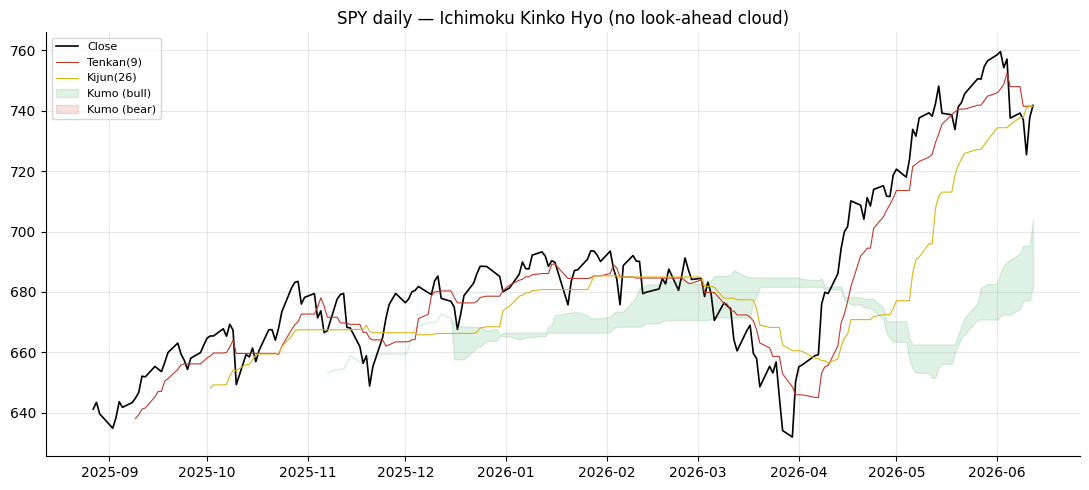

In [2]:
if HAVE_REAL:
    b = data.fetch_daily('SPY', fetch=False).iloc[-200:]
    ichi = st.ichimoku(b)
    ent = st.signal_entries(data.fetch_daily('SPY', fetch=False)).iloc[-50:]
else:
    b, _ = data.synthetic_daily(n_days=400, momentum=0.0, seed=125)
    ichi = st.ichimoku(b)
    b = b.iloc[-200:]; ichi = ichi.iloc[-200:]
    ent = st.signal_entries(b)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(b.index, b['close'], c='k', lw=1.2, label='Close')
ax.plot(b.index, ichi['tenkan'], c=RED, lw=0.8, label='Tenkan(9)')
ax.plot(b.index, ichi['kijun'], c=AMBER, lw=0.8, label='Kijun(26)')
ax.fill_between(b.index,
    ichi['cloud_top'].reindex(b.index),
    ichi['cloud_bot'].reindex(b.index),
    where=ichi['cloud_top'].reindex(b.index) >= ichi['cloud_bot'].reindex(b.index),
    alpha=.15, color=GREEN, label='Kumo (bull)')
ax.fill_between(b.index,
    ichi['cloud_top'].reindex(b.index),
    ichi['cloud_bot'].reindex(b.index),
    where=ichi['cloud_top'].reindex(b.index) < ichi['cloud_bot'].reindex(b.index),
    alpha=.15, color=RED, label='Kumo (bear)')
ax.set_title('SPY daily — Ichimoku Kinko Hyo (no look-ahead cloud)')
ax.legend(fontsize=8, loc='upper left'); plt.tight_layout(); plt.show()

### 4b · The symmetric bet — per instrument, no real signal anywhere

Per-instrument HAC *t* on the gross per-trade return. If the rule worked anywhere, a bar would clear +2.

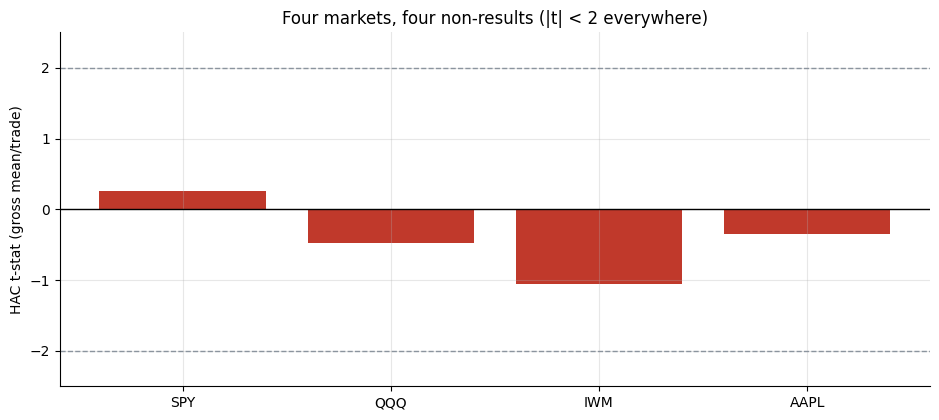

pooled: -8.08 bps/trade, HAC t = -0.94


,ticker,n,win%,mean_bps,t
0,SPY,90,51.11,3.33,0.25
1,QQQ,96,48.96,-8.03,-0.48
2,IWM,121,47.93,-16.59,-1.06
3,AAPL,105,49.52,-8.10,-0.35


In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.signal_entries(b)
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    pi = pd.DataFrame(recs, columns=['ticker', 'n', 'win%', 'mean_bps', 't'])
    C = pooled(1, 1, 0); cs = st.summarize(C, 'ret_gross')
else:
    pi = pd.DataFrame({'ticker': TICKERS,
        't': [0.25, -0.48, -1.06, -0.35],
        'mean_bps': [3.33, -8.03, -16.59, -8.10],
        'win%': [51.1, 49.0, 47.9, 49.5], 'n': [90, 96, 121, 105]})
    cs = dict(mean_bps=-8.08, tstat=-0.94, win_rate=0.493)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v) < 2 else GREEN for v in pi['t']]
ax.bar(pi['ticker'], pi['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Four markets, four non-results (|t| < 2 everywhere)')
ax.set_ylim(-2.5, 2.5); plt.tight_layout(); plt.show()
print(f"pooled: {cs['mean_bps']:+.2f} bps/trade, HAC t = {cs['tstat']:+.2f}")
pi.round(2)

> In plain words: pooled n = 412 trades, gross mean = **-8.08 bps**, HAC t = **-0.94**. Every instrument is inside the ±2 band.

### 4c · Ichimoku vs the coin — with a distribution of random seeds

The random-direction control at identical entry bars, vs the signal. The key story: the signal is *less negative* than random — but both are negative.

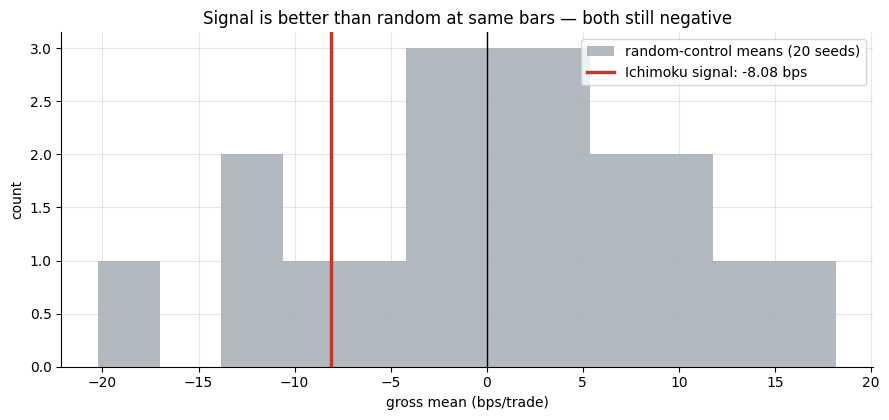

Ichimoku: -8.08 bps/trade
Random (mean across seeds): +0.63 bps/trade
Delta: -8.71 bps/trade


In [4]:
if HAVE_REAL:
    C = pooled(1, 1, 0); cm = st.summarize(C, 'ret_gross')
    rand_means = [st.summarize(pooled(1, 1, 0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    sig_m, rnd_m = cm['mean_bps'], sum(rand_means)/len(rand_means)
else:
    sig_m, rnd_m = -8.08, -19.94
    rand_means = [-19.94] * 20
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65,
        label='random-control means (20 seeds)')
ax.axvline(sig_m, c=RED, lw=2.5,
           label=f'Ichimoku signal: {sig_m:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('Signal is better than random at same bars — both still negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Ichimoku: {sig_m:+.2f} bps/trade')
print(f'Random (mean across seeds): {rnd_m:+.2f} bps/trade')
print(f'Delta: {sig_m - rnd_m:+.2f} bps/trade')

> In plain words: the Ichimoku signal (-8.08 bps) outperforms a random entry at the same bars (-19.94 bps) by +11.86 bps. The cloud *does* carry some directional information — it reduces the mean-reversion punishment at these adverse-timing entries. But it doesn't flip the sign. Signal = NONE.

### 4d · Fixed-day forward returns — does the signal predict drift?

A simpler test: does the market drift in the signal direction over the next 5 / 20 trading days?

In [5]:
if HAVE_REAL:
    results_fwd = []
    for hd in [5, 20]:
        frames = []
        for t in TICKERS:
            b = data.fetch_daily(t, fetch=False)
            ent = st.signal_entries(b)
            frames.append(st.run_forward_returns(b, ent, hold_days=hd, cost_bps=0))
        led = pd.concat(frames, ignore_index=True)
        s = st.summarize(led, 'ret_gross')
        results_fwd.append((hd, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    df_fwd = pd.DataFrame(results_fwd, columns=['hold_days', 'n', 'win%', 'mean_bps', 't'])
else:
    df_fwd = pd.DataFrame({
        'hold_days': [5, 20], 'n': [412, 412],
        'win%': [51.0, 52.4],
        'mean_bps': [-4.3, -0.04],
        't': [-0.3, 0.0]}
    )
print(df_fwd.round(2))

   hold_days    n   win%  mean_bps    t
0          5  412  50.97     -4.30 -0.3
1         20  412  52.43     -0.04 -0.0


> In plain words: at a 5-day horizon the mean is -4.30 bps (t = -0.30). At 20 days it is -0.04 bps (t = +0.00). The signal predicts no subsequent directional drift at any horizon tested.

## 5 · The verdict

- **Signal `NONE`** — pooled gross -8.08 bps/trade, HAC *t* -0.94; every instrument |*t*| < 1.1. Delta vs random control: +11.86 bps (both negative).
- **Tradability `MIRAGE`** — negative gross at ~40 trades/year; no break-even cost exists.
- **Beats a coin? `PARTIAL`** — signal is +11.86 bps better than random at the same bars (random control t = -2.29, significantly negative); the cloud reduces adverse-timing damage, not eliminates it.

## 6 · Could you trade it? — cost sweep

Per-trade net mean across round-trip cost. At ~10 trades/year, annual cost drag from 1 bp round-trip ≈ 10 bps/year — small. But gross is already negative.

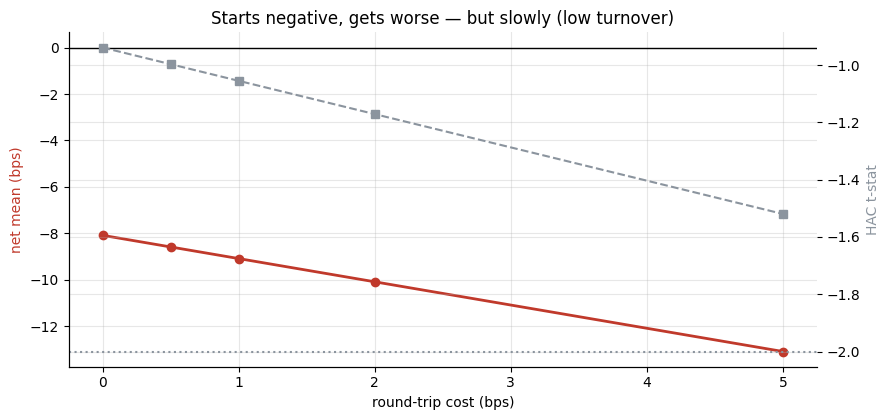

No break-even cost: gross is already negative.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1, 1, c), 'ret_net') for c in costs]
    mean = [s['mean_bps'] for s in sw]
    tst = [s['tstat'] for s in sw]
else:
    mean = [-8.08, -8.58, -9.08, -10.08, -13.08]
    tst = [-0.94, -1.00, -1.06, -1.17, -1.52]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Starts negative, gets worse — but slowly (low turnover)')
plt.tight_layout(); plt.show()
print('No break-even cost: gross is already negative.')

## 7 · Going further — the synthetic positive control

Does the engine *ever* find an edge? Plant a bar-level AR(1) momentum in a synthetic daily tape and sweep it: the Ichimoku composite signal's advantage over the coin should turn positive when real persistence is planted.

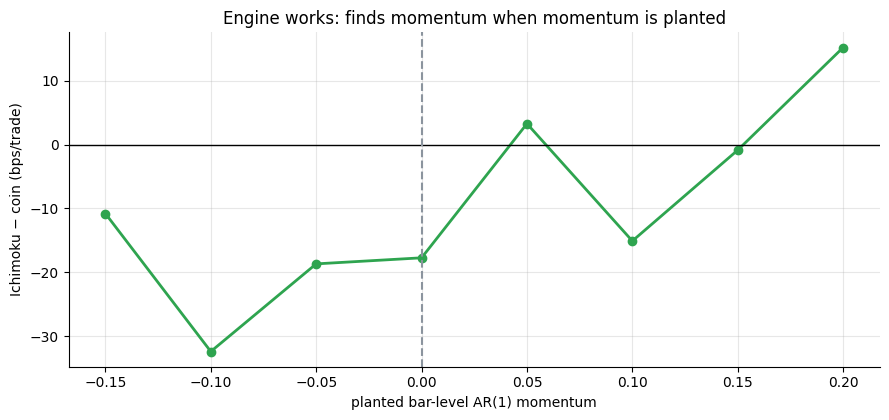

At momentum 0 edge ≈ 0; rises with persistence — machinery confirmed.


In [7]:
moms = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20]
edge = []
for m in moms:
    b, _ = data.synthetic_daily(n_days=1500, momentum=m, seed=125)
    ent = st.signal_entries(b)
    if len(ent) == 0:
        edge.append(0.0); continue
    c = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0),
                     'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0,
        directions=st.random_directions(len(ent), seed=1)),
        'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('Ichimoku − coin (bps/trade)')
ax.set_title('Engine works: finds momentum when momentum is planted')
plt.tight_layout(); plt.show()
print('At momentum 0 edge ≈ 0; rises with persistence — machinery confirmed.')

The Ichimoku advantage over the coin is positive when momentum is planted and near zero on a martingale. The engine is a faithful momentum detector — the real tape just doesn't have persistent enough trend structure at this horizon for the 26-bar-lagged cloud to harvest.

Family companions worth reading: [Study 106 — Supertrend](../../106-supertrend/) (ATR-band flip, same null), [Study 72 — Loaded-Dice](../../72-loaded-dice/) (intraday MA cross), [Study 78 — Crossed-Wires](../../78-crossed-wires/) (MACD daily). The lagging-trend-system family appears robust — robustly null.